# FAILSAFE : SHAP Explainability (XAI)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
print('SHAP version:', shap.__version__)

SHAP version: 0.51.0


In [14]:
model = joblib.load('../models/failsafe_model.pkl')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
feature_names = pd.read_csv('../data/processed/feature_names.csv').squeeze().tolist()
X_test.columns = feature_names
print(f'Model loaded: {type(model).__name__}')
print(f'Test set: {X_test.shape[0]} students, {X_test.shape[1]} features')
print(f'At-risk in test: {sum(y_test==1)} | Passing: {sum(y_test==0)}')

Model loaded: XGBClassifier
Test set: 209 students, 38 features
At-risk in test: 46 | Passing: 163


In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')
print(f'Rows={shap_values.shape[0]} students, Cols={shap_values.shape[1]} features')
print(f'Positive SHAP = pushes toward at-risk')
print(f'Negative SHAP = pushes toward passing')
print(f'Base value: {explainer.expected_value:.4f}')

SHAP values shape: (209, 38)
Rows=209 students, Cols=38 features
Positive SHAP = pushes toward at-risk
Negative SHAP = pushes toward passing
Base value: 0.0190


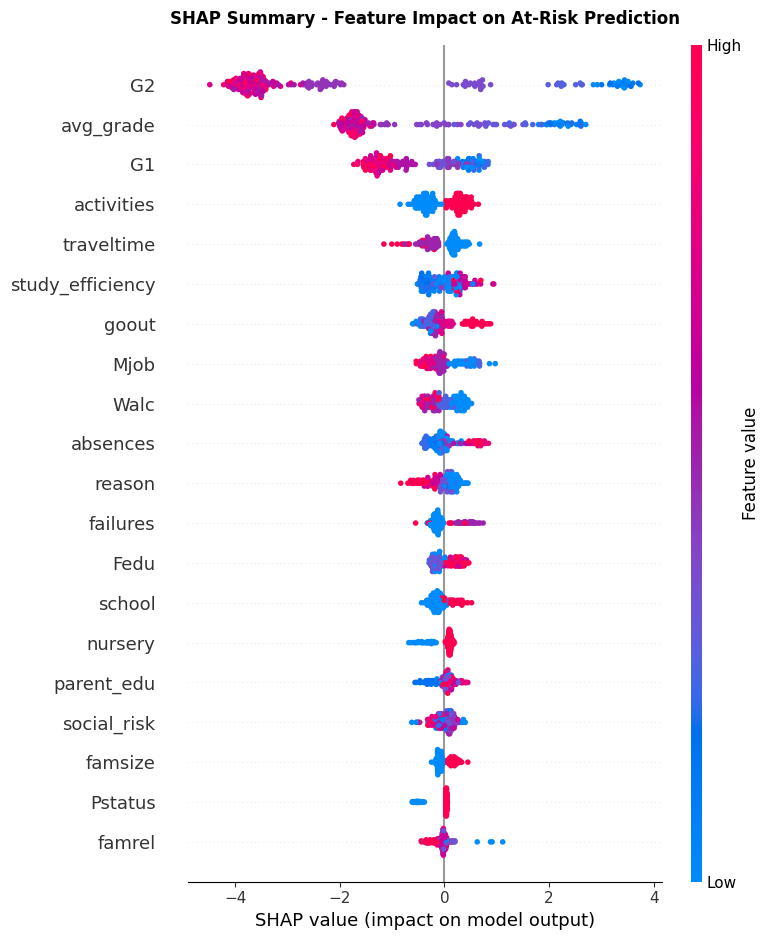

Each dot = one student
X position = SHAP value (right = more at-risk)
Color = feature value (red=high, blue=low)


In [17]:
# Global SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary - Feature Impact on At-Risk Prediction', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/14_shap_summary.png', bbox_inches='tight')
plt.show()
print('Each dot = one student')
print('X position = SHAP value (right = more at-risk)')
print('Color = feature value (red=high, blue=low)')

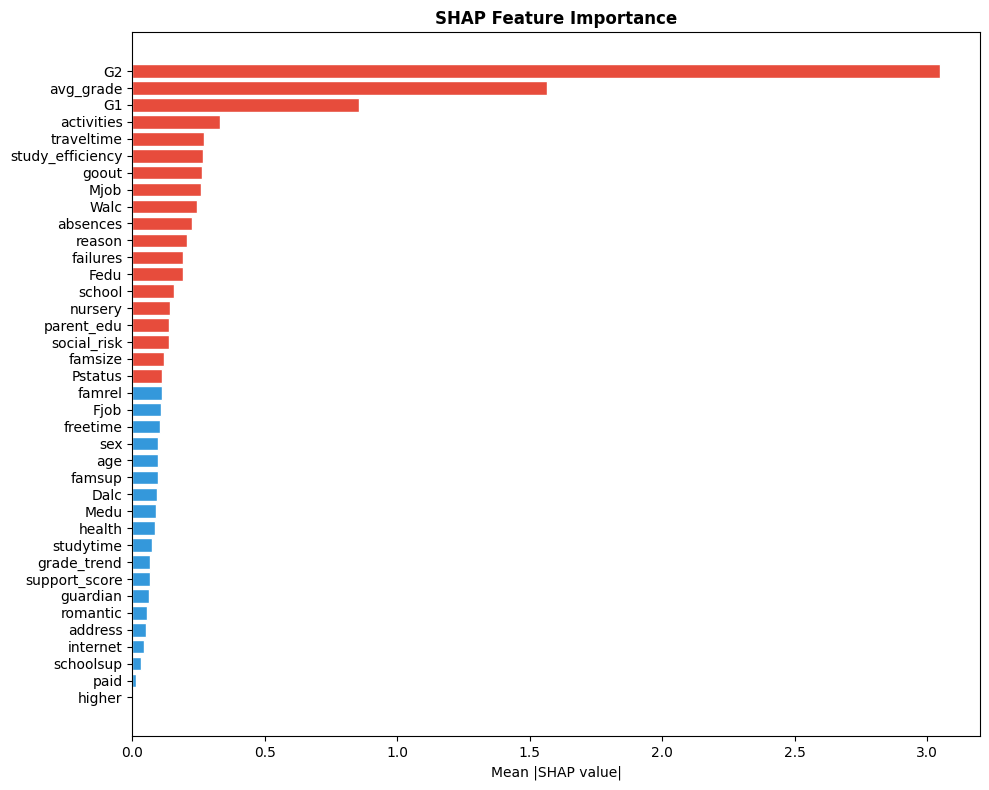

Top 5 features:
       feature  mean_abs_shap
12  traveltime       0.270045
18  activities       0.331227
30          G1       0.854723
33   avg_grade       1.566747
31          G2       3.047152


In [18]:
# SHAP Bar Plot
mean_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > mean_shap['mean_abs_shap'].median() else '#3498db'
          for x in mean_shap['mean_abs_shap']]
plt.barh(mean_shap['feature'], mean_shap['mean_abs_shap'], color=colors, edgecolor='white')
plt.xlabel('Mean |SHAP value|')
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/15_shap_importance.png', bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(mean_shap.tail(5)[['feature', 'mean_abs_shap']].to_string())

In [19]:
def explain_student(student_idx, X_test, y_test, shap_values, feature_names, explainer, save_path=None):
    student_shap = shap_values[student_idx]
    student_features = X_test.iloc[student_idx]
    actual_label = y_test.iloc[student_idx]
    predicted_prob = model.predict_proba(X_test.iloc[[student_idx]])[0][1]
    predicted_label = 1 if predicted_prob >= 0.5 else 0

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'value': student_features.values,
        'shap': student_shap
    }).reindex(pd.Series(np.abs(student_shap)).sort_values(ascending=True).index)
    top_n = shap_df.tail(12)

    fig, ax = plt.subplots(figsize=(11, 7))
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_n['shap']]
    ax.barh(range(len(top_n)), top_n['shap'], color=colors, edgecolor='white', height=0.65)
    for i, (_, row) in enumerate(top_n.iterrows()):
        label = f"{row['feature']} = {row['value']:.2f}"
        x_pos = row['shap'] + (0.003 if row['shap'] >= 0 else -0.003)
        ha = 'left' if row['shap'] >= 0 else 'right'
        ax.text(x_pos, i, label, va='center', ha=ha, fontsize=9)
    ax.axvline(x=0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_yticks([])
    ax.set_xlabel('SHAP Value (safer <- | -> riskier)', fontsize=11)
    status = 'AT-RISK' if predicted_label == 1 else 'PASSING'
    actual = 'at-risk' if actual_label == 1 else 'passing'
    ax.set_title(f'Student #{student_idx} - Predicted: {status} (prob={predicted_prob:.1%}) | Actual: {actual}',
                 fontweight='bold', pad=12)
    red_patch = mpatches.Patch(color='#e74c3c', label='Increases risk')
    green_patch = mpatches.Patch(color='#2ecc71', label='Decreases risk')
    ax.legend(handles=[red_patch, green_patch], loc='lower right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f'Student #{student_idx} | Risk: {predicted_prob:.1%} | Predicted: {status} | Actual: {actual.upper()}')
    risk_factors = shap_df[shap_df['shap'] > 0].sort_values('shap', ascending=False).head(3)
    print('Top risk INCREASING factors:')
    for _, row in risk_factors.iterrows():
        print(f'  {row["feature"]:20s}: value={row["value"]:.2f}, impact=+{row["shap"]:.4f}')
    safe_factors = shap_df[shap_df['shap'] < 0].sort_values('shap').head(3)
    print('Top risk DECREASING factors:')
    for _, row in safe_factors.iterrows():
        print(f'  {row["feature"]:20s}: value={row["value"]:.2f}, impact={row["shap"]:.4f}')



Correctly caught at-risk students: 37


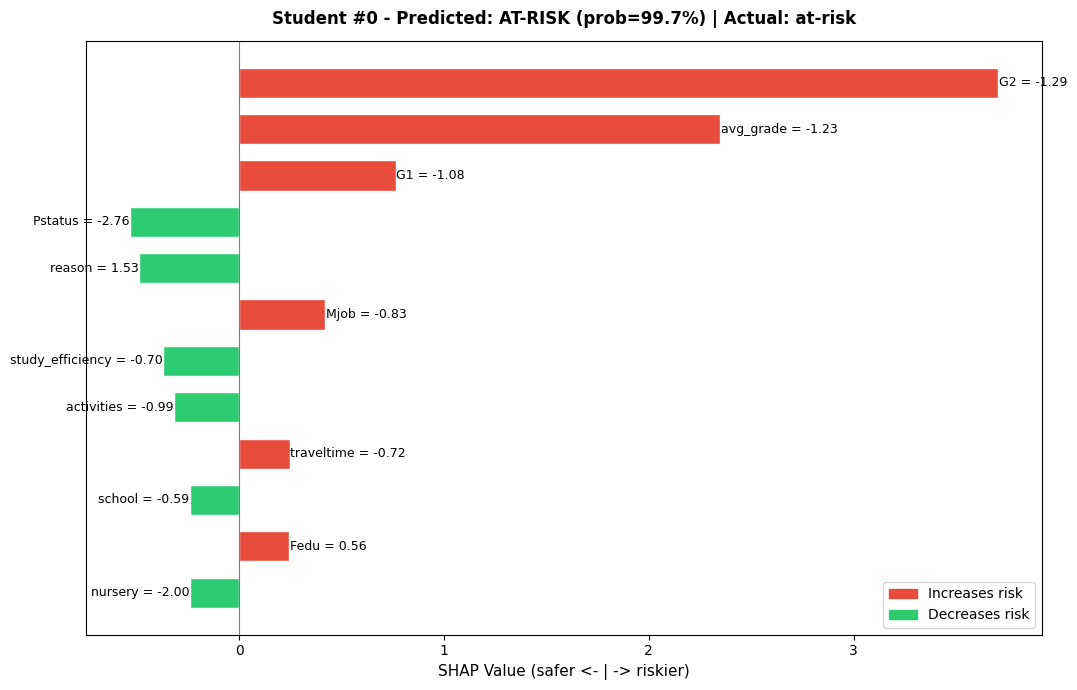

Student #0 | Risk: 99.7% | Predicted: AT-RISK | Actual: AT-RISK
Top risk INCREASING factors:
  G2                  : value=-1.29, impact=+3.7069
  avg_grade           : value=-1.23, impact=+2.3479
  G1                  : value=-1.08, impact=+0.7633
Top risk DECREASING factors:
  Pstatus             : value=-2.76, impact=-0.5358
  reason              : value=1.53, impact=-0.4915
  study_efficiency    : value=-0.70, impact=-0.3720


In [20]:
y_pred = model.predict(X_test)
true_positives = np.where((y_test == 1) & (y_pred == 1))[0]
print(f'Correctly caught at-risk students: {len(true_positives)}')
explain_student(true_positives[0], X_test, y_test, shap_values, feature_names, explainer,
                save_path='../reports/16_shap_atrisk_student.png')

Correctly classified passing students: 151


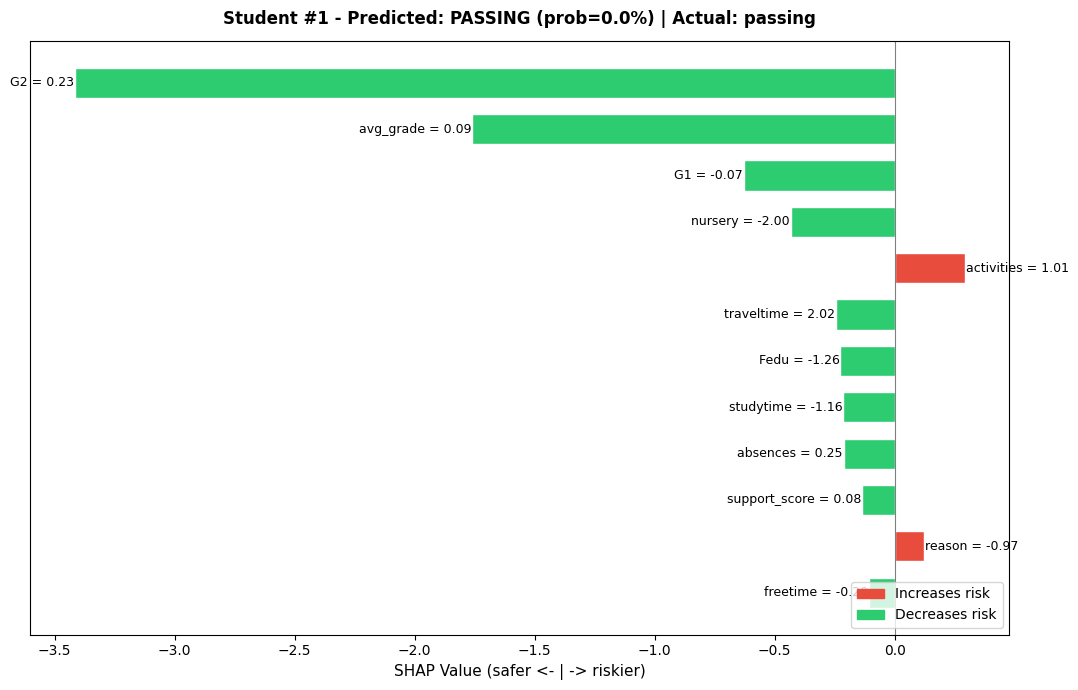

Student #1 | Risk: 0.0% | Predicted: PASSING | Actual: PASSING
Top risk INCREASING factors:
  activities          : value=1.01, impact=+0.2923
  reason              : value=-0.97, impact=+0.1218
  Mjob                : value=-1.63, impact=+0.1018
Top risk DECREASING factors:
  G2                  : value=0.23, impact=-3.4166
  avg_grade           : value=0.09, impact=-1.7619
  G1                  : value=-0.07, impact=-0.6298


In [21]:
true_negatives = np.where((y_test == 0) & (y_pred == 0))[0]
print(f'Correctly classified passing students: {len(true_negatives)}')
explain_student(true_negatives[0], X_test, y_test, shap_values, feature_names, explainer,
                save_path='../reports/17_shap_passing_student.png')

In [22]:
INTERVENTION_RULES = {
    'absences':       {'threshold': 0.05, 'message': 'High absences detected.',
                       'action': 'Schedule attendance review. Contact parents. Check for underlying issues.'},
    'failures':       {'threshold': 0.05, 'message': 'History of past failures.',
                       'action': 'Enrol in remedial classes. Assign academic mentor.'},
    'studytime':      {'threshold': 0.03, 'message': 'Low study time.',
                       'action': 'Provide structured study plan. Recommend study groups.'},
    'G1':             {'threshold': 0.05, 'message': 'Poor Period 1 grade.',
                       'action': 'Arrange extra tutoring. Weekly check-ins with subject teacher.'},
    'G2':             {'threshold': 0.05, 'message': 'Poor Period 2 grade.',
                       'action': 'Urgent intervention. Refer to counsellor. Discuss with HOD.'},
    'grade_trend':    {'threshold': 0.03, 'message': 'Declining grade trend.',
                       'action': 'Monitor weekly. Identify what changed between periods.'},
    'avg_grade':      {'threshold': 0.05, 'message': 'Low average grade.',
                       'action': 'Full academic review with HOD. Personalised learning plan.'},
    'social_risk':    {'threshold': 0.03, 'message': 'High social risk score.',
                       'action': 'Refer to counsellor. Engage parents.'},
    'goout':          {'threshold': 0.03, 'message': 'Frequently going out.',
                       'action': 'Counselling session. Time management strategies.'},
    'study_efficiency': {'threshold': 0.03, 'message': 'Low study efficiency.',
                         'action': 'Check home study environment. Recommend library.'}
}

def generate_intervention_plan(student_idx, X_test, shap_values, feature_names):
    student_shap = shap_values[student_idx]
    predicted_prob = model.predict_proba(X_test.iloc[[student_idx]])[0][1]
    risk_factors = [(feature_names[i], student_shap[i])
                    for i in np.argsort(student_shap)[::-1] if student_shap[i] > 0]
    print('=' * 60)
    print(f'  FAILSAFE INTERVENTION PLAN - Student #{student_idx}')
    print('=' * 60)
    level = 'HIGH' if predicted_prob >= 0.7 else 'MODERATE' if predicted_prob >= 0.5 else 'LOW'
    print(f'  Risk Score: {predicted_prob:.1%}  |  {level} RISK')
    print('-' * 60)
    count = 0
    for feature, shap_val in risk_factors:
        if feature in INTERVENTION_RULES:
            rule = INTERVENTION_RULES[feature]
            if shap_val >= rule['threshold']:
                count += 1
                print(f'  [{count}] {rule["message"]}')
                print(f'      SHAP: +{shap_val:.4f}')
                print(f'      Action: {rule["action"]}')
                print()
    if count == 0:
        print('  Monitor student weekly.')
    print('=' * 60)

In [23]:
for idx in true_positives[:3]:
    generate_intervention_plan(idx, X_test, shap_values, feature_names)
    print()

  FAILSAFE INTERVENTION PLAN - Student #0
  Risk Score: 99.7%  |  HIGH RISK
------------------------------------------------------------
  [1] Poor Period 2 grade.
      SHAP: +3.7069
      Action: Urgent intervention. Refer to counsellor. Discuss with HOD.

  [2] Low average grade.
      SHAP: +2.3479
      Action: Full academic review with HOD. Personalised learning plan.

  [3] Poor Period 1 grade.
      SHAP: +0.7633
      Action: Arrange extra tutoring. Weekly check-ins with subject teacher.

  [4] High social risk score.
      SHAP: +0.1784
      Action: Refer to counsellor. Engage parents.


  FAILSAFE INTERVENTION PLAN - Student #5
  Risk Score: 99.7%  |  HIGH RISK
------------------------------------------------------------
  [1] Poor Period 2 grade.
      SHAP: +2.2408
      Action: Urgent intervention. Refer to counsellor. Discuss with HOD.

  [2] Low average grade.
      SHAP: +2.0292
      Action: Full academic review with HOD. Personalised learning plan.

  [3] Poor Perio

Most important feature: G2


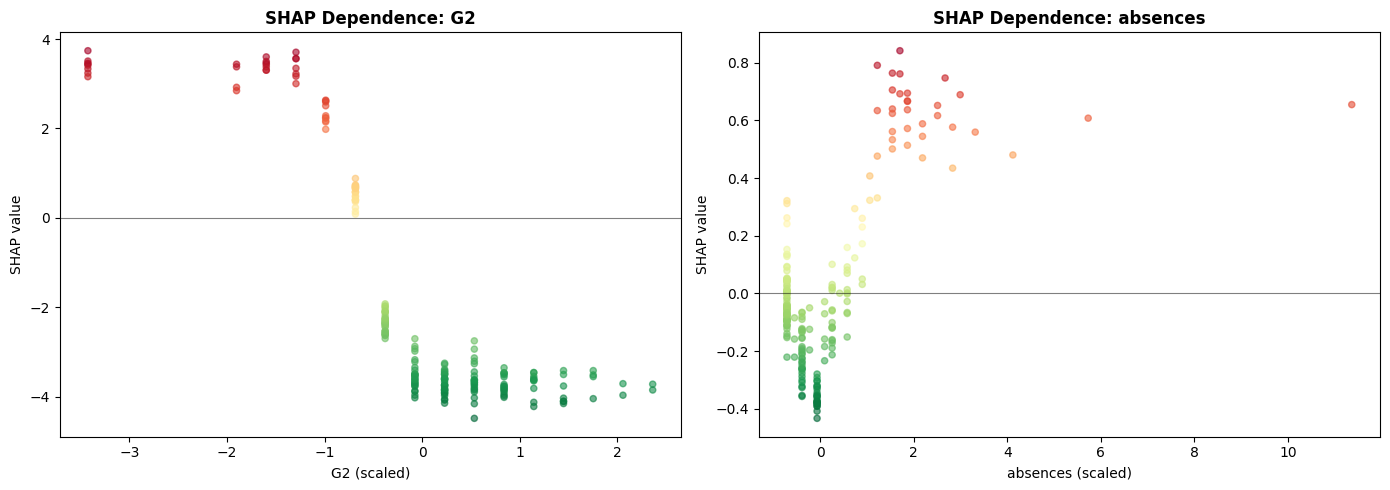

In [24]:
# SHAP Dependence Plots
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature = feature_names[top_feature_idx]
print(f'Most important feature: {top_feature}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_test.iloc[:, top_feature_idx], shap_values[:, top_feature_idx],
                c=shap_values[:, top_feature_idx], cmap='RdYlGn_r', alpha=0.6, s=20)
axes[0].axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel(f'{top_feature} (scaled)')
axes[0].set_ylabel('SHAP value')
axes[0].set_title(f'SHAP Dependence: {top_feature}', fontweight='bold')

if 'absences' in feature_names:
    abs_idx = feature_names.index('absences')
    axes[1].scatter(X_test.iloc[:, abs_idx], shap_values[:, abs_idx],
                    c=shap_values[:, abs_idx], cmap='RdYlGn_r', alpha=0.6, s=20)
    axes[1].axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
    axes[1].set_xlabel('absences (scaled)')
    axes[1].set_ylabel('SHAP value')
    axes[1].set_title('SHAP Dependence: absences', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/18_shap_dependence.png', bbox_inches='tight')
plt.show()

In [25]:
joblib.dump(explainer, '../models/shap_explainer.pkl')
with open('../models/intervention_rules.json', 'w') as f:
    json.dump(INTERVENTION_RULES, f, indent=2)
print('Saved: models/shap_explainer.pkl')
print('Saved: models/intervention_rules.json')

Saved: models/shap_explainer.pkl
Saved: models/intervention_rules.json
